# Iteration 2 — Inducing Misclassification via Feature Removal
**Goal:** Progressively remove features (by entropy contribution) until the model produces FP/FN, then apply a profit matrix and analyse errors.

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)
from scipy.stats import entropy as scipy_entropy
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'font.family':      'sans-serif',
    'axes.titlesize':   14,
    'axes.labelsize':   11,
    'font.size':        10,
})
EDIBLE_COLOR  = '#2ecc71'
POISON_COLOR  = '#e74c3c'
PALETTE       = [EDIBLE_COLOR, POISON_COLOR]

print('Imports loaded.')

Imports loaded.


In [2]:
# ── Load & Encode ──
df = pd.read_csv('mushrooms.csv')

df_encoded = df.copy()
le_dict = {}
for col in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le

# Drop veil-type (single unique value)
if df['veil-type'].nunique() == 1:
    df_encoded.drop('veil-type', axis=1, inplace=True)

print(f'Dataset: {df.shape[0]:,} samples × {df.shape[1]} features')

Dataset: 8,124 samples × 23 features


## Step 1 — Compute Conditional Entropy of Each Feature w.r.t. Class

For each feature $X_j$, we calculate $H(Y | X_j)$ — the remaining uncertainty about the class given that feature. **Lower** conditional entropy = **more informative** feature. We will remove features starting from the **most informative** (lowest conditional entropy) to degrade the model.

In [3]:
def conditional_entropy(df, feature, target='class'):
    """H(target | feature) — how much uncertainty remains about target given feature."""
    ce = 0.0
    for val in df[feature].unique():
        subset = df[df[feature] == val][target]
        p = len(subset) / len(df)
        probs = subset.value_counts(normalize=True).values
        ce += p * scipy_entropy(probs, base=2)
    return ce

features = [c for c in df_encoded.columns if c != 'class']
cond_ent = {f: conditional_entropy(df_encoded, f) for f in features}
cond_ent_series = pd.Series(cond_ent).sort_values()

print('Conditional Entropy H(class | feature) — lower = more informative:')
print(cond_ent_series.to_string())

Conditional Entropy H(class | feature) — lower = more informative:
odor                        0.092993
spore-print-color           0.518363
gill-color                  0.582090
ring-type                   0.681046
stalk-surface-above-ring    0.714342
stalk-surface-below-ring    0.727173
stalk-color-above-ring      0.745223
stalk-color-below-ring      0.757652
gill-size                   0.768914
population                  0.797110
bruises                     0.806688
habitat                     0.842234
stalk-root                  0.864250
gill-spacing                0.898185
cap-shape                   0.950271
ring-number                 0.960615
cap-color                   0.963019
cap-surface                 0.970478
veil-color                  0.975251
gill-attachment             0.984903
stalk-shape                 0.991551


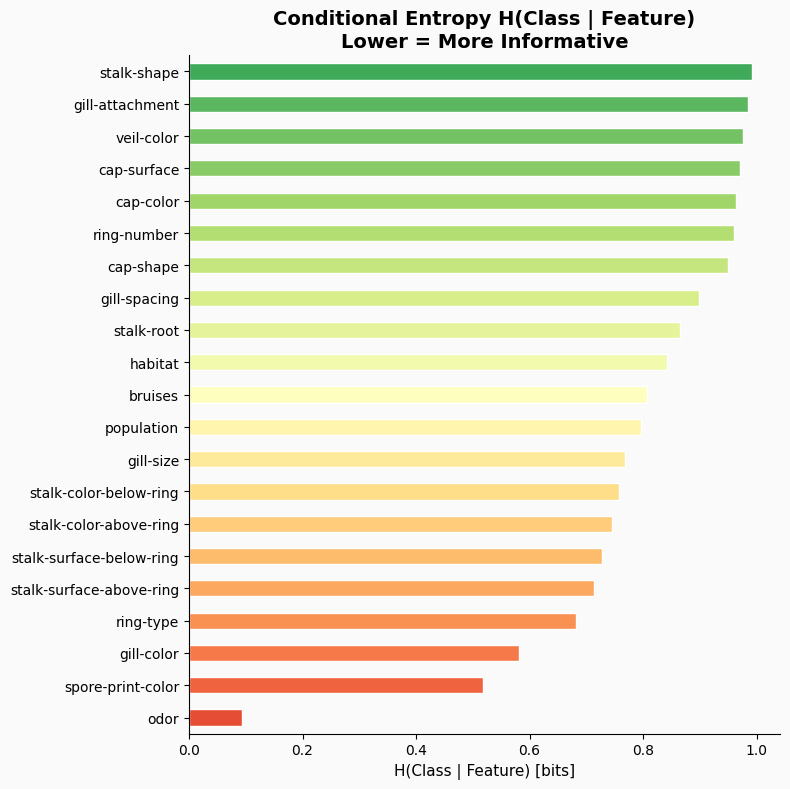

In [4]:
# ── Visualise the entropy ranking ──
fig, ax = plt.subplots(figsize=(8, 8))
colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(cond_ent_series)))
cond_ent_series.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Conditional Entropy H(Class | Feature)\nLower = More Informative',
             fontweight='bold')
ax.set_xlabel('H(Class | Feature) [bits]')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Step 2 — Progressive Feature Removal Until Misclassification

We remove features one-by-one, starting with the **most informative** (lowest conditional entropy), and retrain a Decision Tree each time. We stop when FP + FN > 0.

In [5]:
removal_order = cond_ent_series.index.tolist()  # most informative first

X_full = df_encoded.drop('class', axis=1)
y = df_encoded['class']

results = []
removed = []

for feat in removal_order:
    removed.append(feat)
    remaining = [c for c in X_full.columns if c not in removed]
    
    if len(remaining) == 0:
        break
    
    X_sub = X_full[remaining]
    X_tr, X_te, y_tr, y_te = train_test_split(X_sub, y, test_size=0.3,
                                               random_state=42, stratify=y)
    dt = DecisionTreeClassifier(random_state=42)
    dt.fit(X_tr, y_tr)
    y_pred = dt.predict(X_te)
    cm = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(y_te, y_pred)
    
    results.append({
        'removed': feat,
        'n_removed': len(removed),
        'n_remaining': len(remaining),
        'accuracy': acc,
        'FP': fp, 'FN': fn, 'TP': tp, 'TN': tn
    })
    
    print(f'Removed {len(removed):2d}: {feat:30s} | Remaining: {len(remaining):2d} | '
          f'Acc: {acc*100:6.2f}% | FP: {fp:3d} | FN: {fn:3d}')
    
    if fp + fn > 0 and len(removed) >= 2:
        # Continue a few more to see the trend
        pass

results_df = pd.DataFrame(results)
results_df

Removed  1: odor                           | Remaining: 20 | Acc: 100.00% | FP:   0 | FN:   0
Removed  2: spore-print-color              | Remaining: 19 | Acc: 100.00% | FP:   0 | FN:   0
Removed  3: gill-color                     | Remaining: 18 | Acc: 100.00% | FP:   0 | FN:   0
Removed  4: ring-type                      | Remaining: 17 | Acc: 100.00% | FP:   0 | FN:   0
Removed  5: stalk-surface-above-ring       | Remaining: 16 | Acc: 100.00% | FP:   0 | FN:   0
Removed  6: stalk-surface-below-ring       | Remaining: 15 | Acc: 100.00% | FP:   0 | FN:   0
Removed  7: stalk-color-above-ring         | Remaining: 14 | Acc: 100.00% | FP:   0 | FN:   0
Removed  8: stalk-color-below-ring         | Remaining: 13 | Acc: 100.00% | FP:   0 | FN:   0
Removed  9: gill-size                      | Remaining: 12 | Acc: 100.00% | FP:   0 | FN:   0
Removed 10: population                     | Remaining: 11 | Acc: 100.00% | FP:   0 | FN:   0
Removed 11: bruises                        | Remaining: 10 |

,removed,n_removed,n_remaining,accuracy,FP,FN,TP,TN
0,odor,1,20,1.000000,0,0,1175,1263
1,spore-print-color,2,19,1.000000,0,0,1175,1263
2,gill-color,3,18,1.000000,0,0,1175,1263
3,ring-type,4,17,1.000000,0,0,1175,1263
4,stalk-surface-above-ring,5,16,1.000000,0,0,1175,1263
5,stalk-surface-below-ring,6,15,1.000000,0,0,1175,1263
6,stalk-color-above-ring,7,14,1.000000,0,0,1175,1263
7,stalk-color-below-ring,8,13,1.000000,0,0,1175,1263
8,gill-size,9,12,1.000000,0,0,1175,1263
9,population,10,11,1.000000,0,0,1175,1263


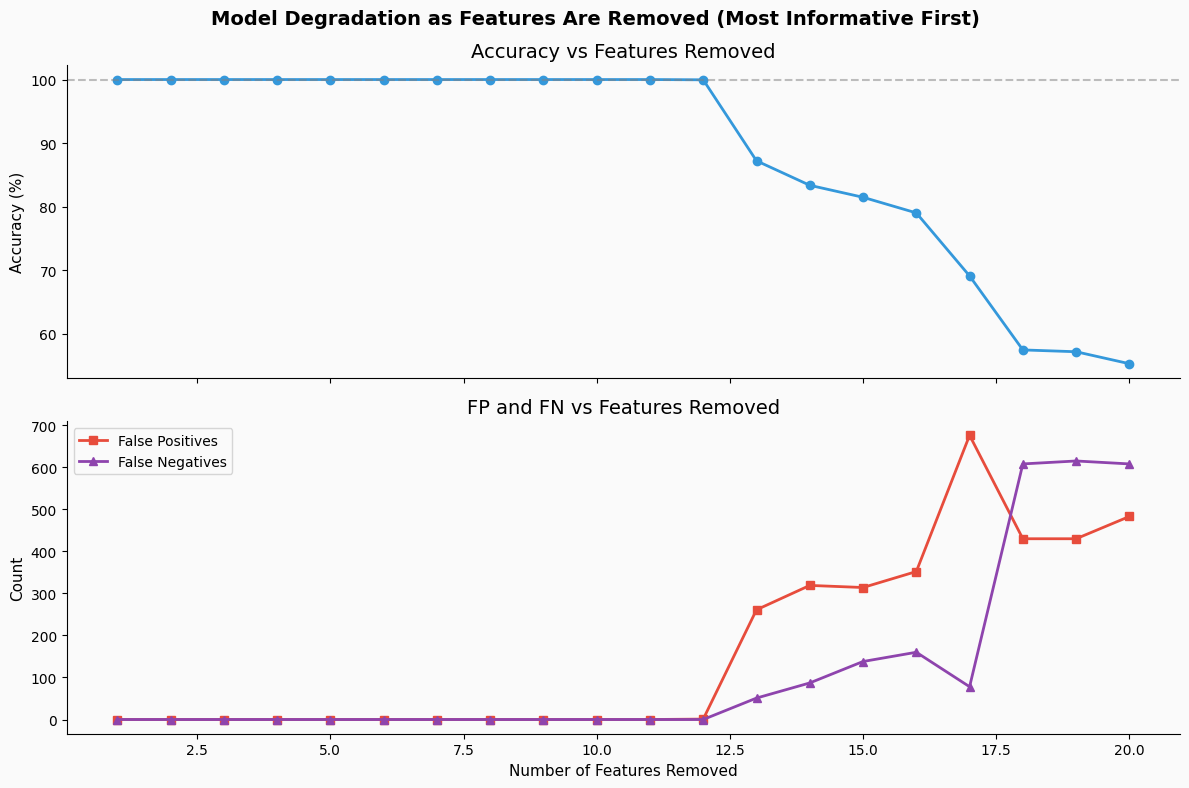

In [6]:
# ── Plot accuracy degradation ──
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle('Model Degradation as Features Are Removed (Most Informative First)',
             fontweight='bold', fontsize=14)

ax1.plot(results_df['n_removed'], results_df['accuracy']*100, 'o-', color='#3498db', lw=2)
ax1.set_ylabel('Accuracy (%)')
ax1.axhline(100, color='gray', ls='--', alpha=0.5)
ax1.spines[['top', 'right']].set_visible(False)
ax1.set_title('Accuracy vs Features Removed')

ax2.plot(results_df['n_removed'], results_df['FP'], 's-', color=POISON_COLOR, lw=2, label='False Positives')
ax2.plot(results_df['n_removed'], results_df['FN'], '^-', color='#8e44ad', lw=2, label='False Negatives')
ax2.set_xlabel('Number of Features Removed')
ax2.set_ylabel('Count')
ax2.legend()
ax2.spines[['top', 'right']].set_visible(False)
ax2.set_title('FP and FN vs Features Removed')

plt.tight_layout()
plt.show()

## Step 3 — Select the Degraded Feature Set

We pick the point where misclassification first appears meaningfully and use that reduced feature set for the rest of the analysis.

In [7]:
# Find first row where FP+FN > 0
misclass_rows = results_df[(results_df['FP'] + results_df['FN']) > 0]
if len(misclass_rows) > 0:
    first_misclass = misclass_rows.iloc[0]
    n_to_remove = int(first_misclass['n_removed'])
else:
    # If still perfect after all removals, take the last few
    n_to_remove = len(removal_order) - 5

# Use a few more removals past the first misclassification to get meaningful errors
# Find the sweet spot: enough errors to analyse but not total collapse
candidates = results_df[(results_df['FP'] + results_df['FN']) > 5]
if len(candidates) > 0:
    best_row = candidates.iloc[0]
    n_to_remove = int(best_row['n_removed'])
else:
    n_to_remove = max(n_to_remove, int(results_df.iloc[-1]['n_removed']) - 3)

dropped_features = removal_order[:n_to_remove]
kept_features = [c for c in X_full.columns if c not in dropped_features]

print(f'Removing {n_to_remove} features: {dropped_features}')
print(f'Keeping {len(kept_features)} features: {kept_features}')

Removing 13 features: ['odor', 'spore-print-color', 'gill-color', 'ring-type', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'gill-size', 'population', 'bruises', 'habitat', 'stalk-root']
Keeping 8 features: ['cap-shape', 'cap-surface', 'cap-color', 'gill-attachment', 'gill-spacing', 'stalk-shape', 'veil-color', 'ring-number']


In [8]:
# ── Train on reduced feature set ──
X_reduced = X_full[kept_features]
X_tr, X_te, y_tr, y_te = train_test_split(X_reduced, y, test_size=0.3,
                                           random_state=42, stratify=y)

dt_reduced = DecisionTreeClassifier(random_state=42)
dt_reduced.fit(X_tr, y_tr)
y_pred_reduced = dt_reduced.predict(X_te)

cm_reduced = confusion_matrix(y_te, y_pred_reduced)
tn, fp, fn, tp = cm_reduced.ravel()
acc_reduced = accuracy_score(y_te, y_pred_reduced)

print(f'Reduced Model — Accuracy: {acc_reduced*100:.2f}%')
print(f'TN: {tn}  FP: {fp}  FN: {fn}  TP: {tp}')
print(f'\n{classification_report(y_te, y_pred_reduced, target_names=["Edible", "Poisonous"])}')

Reduced Model — Accuracy: 87.20%
TN: 1002  FP: 261  FN: 51  TP: 1124

              precision    recall  f1-score   support

      Edible       0.95      0.79      0.87      1263
   Poisonous       0.81      0.96      0.88      1175

    accuracy                           0.87      2438
   macro avg       0.88      0.87      0.87      2438
weighted avg       0.88      0.87      0.87      2438



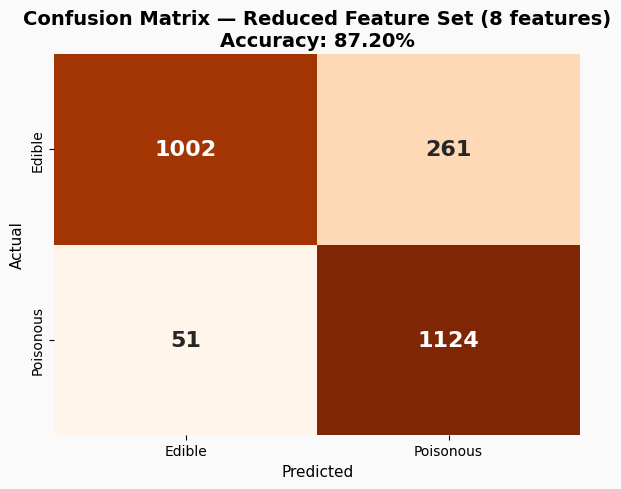

In [9]:
# ── Confusion Matrix for reduced model ──
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_reduced, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'],
            ax=ax, cbar=False,
            annot_kws={'size': 16, 'fontweight': 'bold'})
ax.set_title(f'Confusion Matrix — Reduced Feature Set ({len(kept_features)} features)\n'
             f'Accuracy: {acc_reduced*100:.2f}%', fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

## Step 4 — Profit Matrix Analysis

In a mushroom safety context, **False Negatives are far worse than False Positives**:
- **FN** (poisonous predicted edible) → someone eats a toxic mushroom → **catastrophic**
- **FP** (edible predicted poisonous) → a safe mushroom is discarded → **minor loss**

We define a profit/cost matrix with subjective weights reflecting this asymmetry.

In [10]:
# ── Profit Matrix ──
# Convention: class 0 = edible, class 1 = poisonous
# Positive outcome = correctly handling mushroom

PROFIT_MATRIX = {
    'TP': +50,   # Correctly identify poisonous → life saved
    'TN': +10,   # Correctly identify edible → enjoy mushroom
    'FP': -5,    # Edible classified as poisonous → waste food
    'FN': -1000, # Poisonous classified as edible → potential death
}

print('Profit Matrix:')
print(f'  True Positive  (correctly flag poison):  {PROFIT_MATRIX["TP"]:+d}')
print(f'  True Negative  (correctly flag edible):  {PROFIT_MATRIX["TN"]:+d}')
print(f'  False Positive (edible flagged poison):  {PROFIT_MATRIX["FP"]:+d}')
print(f'  False Negative (poison flagged edible):  {PROFIT_MATRIX["FN"]:+d}')
print(f'\nThe FN cost is {abs(PROFIT_MATRIX["FN"])//abs(PROFIT_MATRIX["FP"])}x the FP cost — '
      f'reflecting that eating a toxic mushroom is catastrophic.')

Profit Matrix:
  True Positive  (correctly flag poison):  +50
  True Negative  (correctly flag edible):  +10
  False Positive (edible flagged poison):  -5
  False Negative (poison flagged edible):  -1000

The FN cost is 200x the FP cost — reflecting that eating a toxic mushroom is catastrophic.


In [11]:
def compute_profit(y_true, y_pred, profit_matrix):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    total = (tp * profit_matrix['TP'] + tn * profit_matrix['TN'] +
             fp * profit_matrix['FP'] + fn * profit_matrix['FN'])
    return total, {'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn}

profit_reduced, counts_reduced = compute_profit(y_te, y_pred_reduced, PROFIT_MATRIX)
print(f'Reduced model profit: {profit_reduced:+,}')
print(f'Counts: {counts_reduced}')

Reduced model profit: +13,915
Counts: {'TP': np.int64(1124), 'TN': np.int64(1002), 'FP': np.int64(261), 'FN': np.int64(51)}


## Step 5 — Retrain with Cost-Sensitive Learning

We use `class_weight` to penalise FN more heavily, pushing the model to be conservative (predict poisonous when uncertain).

In [12]:
# The ratio of FN cost to FP cost determines the class weight
fn_fp_ratio = abs(PROFIT_MATRIX['FN']) / abs(PROFIT_MATRIX['FP'])
# class 1 (poisonous) gets higher weight so the model avoids missing it
class_weights = {0: 1, 1: fn_fp_ratio}

dt_cost = DecisionTreeClassifier(random_state=42, class_weight=class_weights)
dt_cost.fit(X_tr, y_tr)
y_pred_cost = dt_cost.predict(X_te)

cm_cost = confusion_matrix(y_te, y_pred_cost)
tn_c, fp_c, fn_c, tp_c = cm_cost.ravel()
acc_cost = accuracy_score(y_te, y_pred_cost)

profit_cost, counts_cost = compute_profit(y_te, y_pred_cost, PROFIT_MATRIX)

print(f'Cost-Sensitive Model — Accuracy: {acc_cost*100:.2f}%')
print(f'TN: {tn_c}  FP: {fp_c}  FN: {fn_c}  TP: {tp_c}')
print(f'Profit: {profit_cost:+,}')
print(f'\n{classification_report(y_te, y_pred_cost, target_names=["Edible", "Poisonous"])}')

Cost-Sensitive Model — Accuracy: 84.86%
TN: 894  FP: 369  FN: 0  TP: 1175
Profit: +65,845

              precision    recall  f1-score   support

      Edible       1.00      0.71      0.83      1263
   Poisonous       0.76      1.00      0.86      1175

    accuracy                           0.85      2438
   macro avg       0.88      0.85      0.85      2438
weighted avg       0.88      0.85      0.85      2438



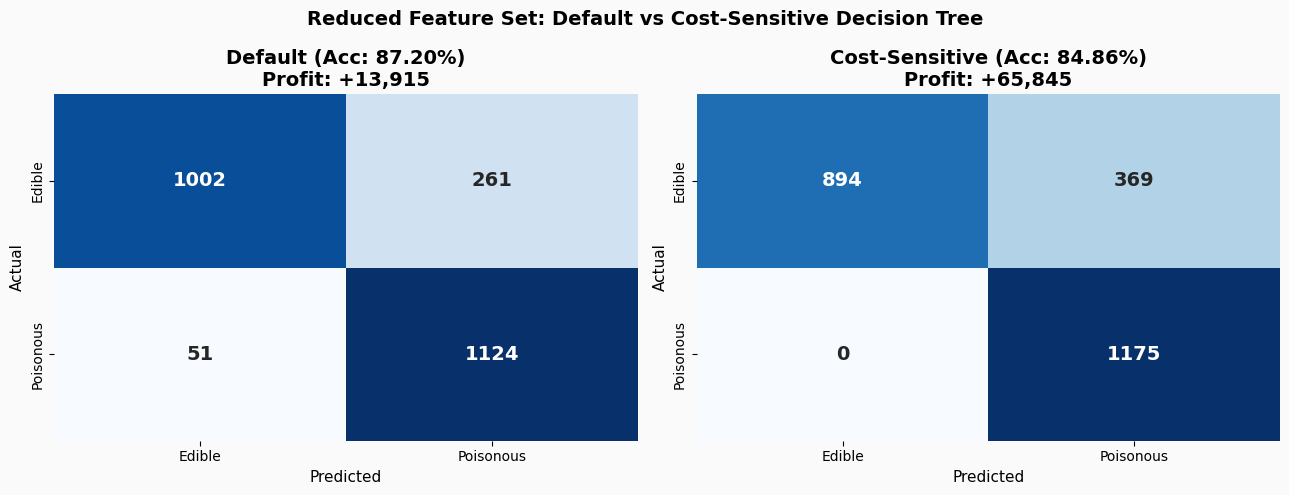

In [13]:
# ── Side-by-side confusion matrices ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Reduced Feature Set: Default vs Cost-Sensitive Decision Tree',
             fontweight='bold', fontsize=14)

for ax, cm, title, profit in zip(
    axes,
    [cm_reduced, cm_cost],
    [f'Default (Acc: {acc_reduced*100:.2f}%)', f'Cost-Sensitive (Acc: {acc_cost*100:.2f}%)'],
    [profit_reduced, profit_cost]
):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Edible', 'Poisonous'],
                yticklabels=['Edible', 'Poisonous'],
                annot_kws={'size': 14, 'fontweight': 'bold'})
    ax.set_title(f'{title}\nProfit: {profit:+,}', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## Step 6 — Analyse Misclassified Observations

We examine which samples the reduced model gets wrong and compare FP vs FN patterns.

In [14]:
# ── Identify misclassified samples ──
test_results = X_te.copy()
test_results['actual'] = y_te.values
test_results['predicted'] = y_pred_reduced
test_results['correct'] = (y_te.values == y_pred_reduced)

# Classify error type
def error_type(row):
    if row['correct']:
        return 'Correct'
    elif row['actual'] == 0 and row['predicted'] == 1:
        return 'FP (edible → poison)'
    else:
        return 'FN (poison → edible)'

test_results['error_type'] = test_results.apply(error_type, axis=1)

print('Error breakdown:')
print(test_results['error_type'].value_counts())

# Get just the misclassified
misclassified = test_results[~test_results['correct']].copy()
fp_samples = misclassified[misclassified['error_type'].str.startswith('FP')]
fn_samples = misclassified[misclassified['error_type'].str.startswith('FN')]

print(f'\nFP samples: {len(fp_samples)}')
print(f'FN samples: {len(fn_samples)}')

Error breakdown:
error_type
Correct                 2126
FP (edible → poison)     261
FN (poison → edible)      51
Name: count, dtype: int64

FP samples: 261
FN samples: 51


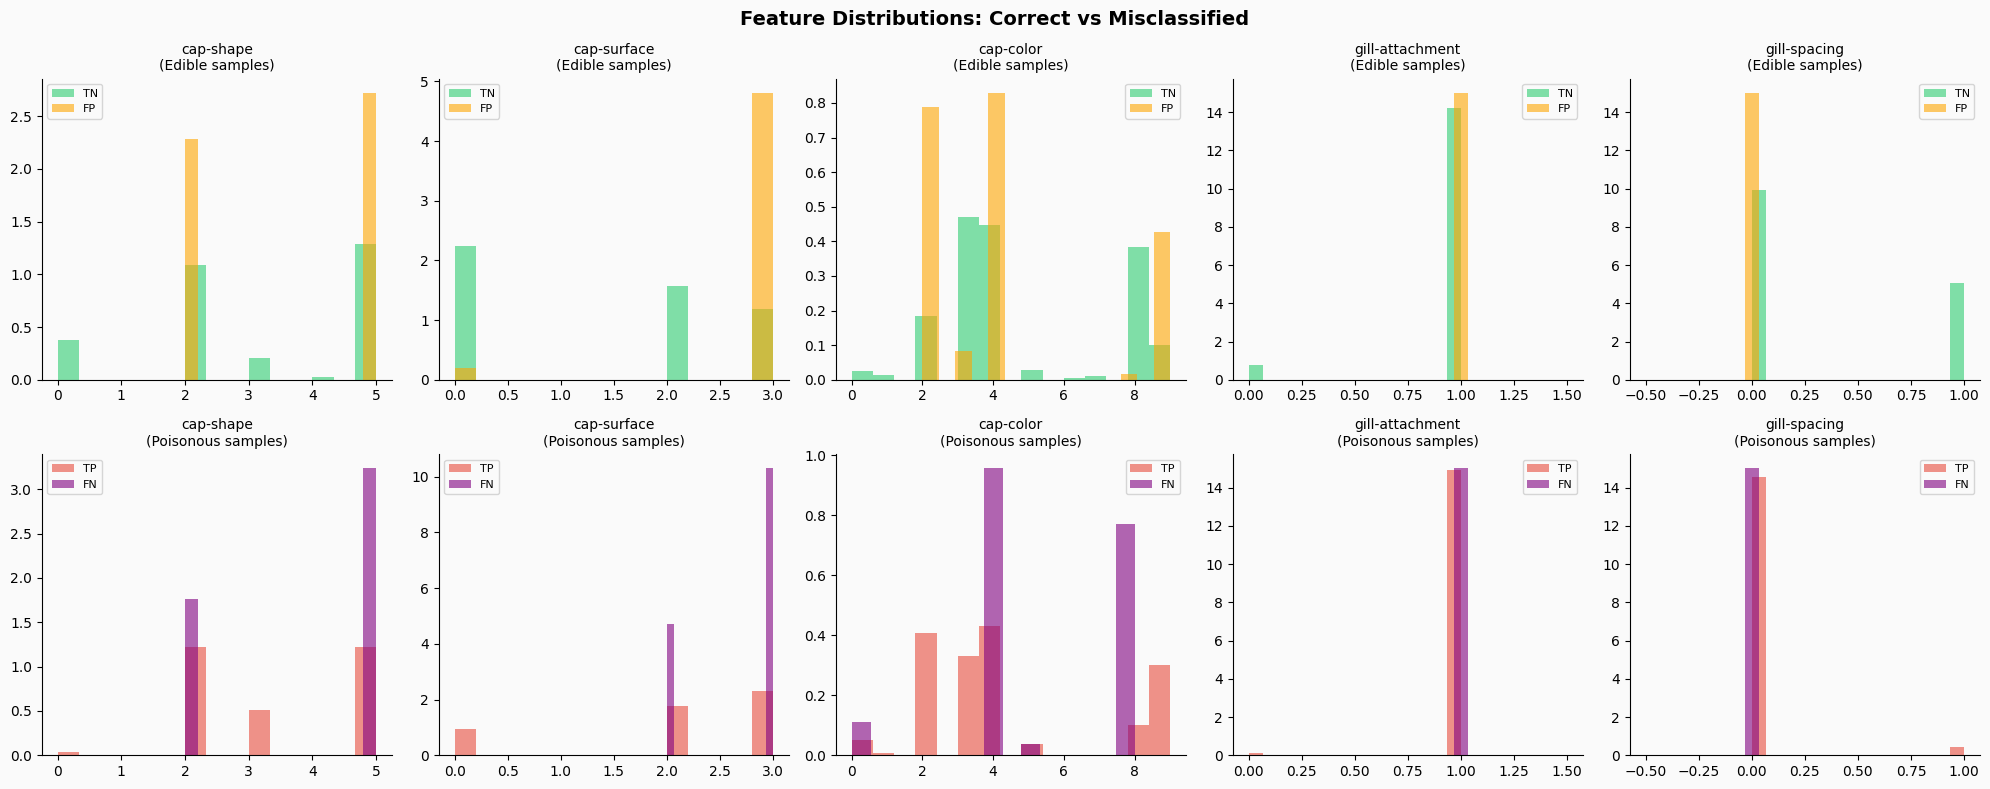

In [15]:
# ── Visualise feature distributions: FP vs TN and FN vs TP ──
if len(misclassified) > 0:
    fig, axes = plt.subplots(2, min(len(kept_features), 5), 
                             figsize=(4*min(len(kept_features), 5), 8))
    fig.suptitle('Feature Distributions: Correct vs Misclassified',
                 fontweight='bold', fontsize=14)
    
    plot_features = kept_features[:5]  # top 5 remaining
    
    for j, feat in enumerate(plot_features):
        # Row 1: Edible samples — TN vs FP
        ax = axes[0, j] if len(plot_features) > 1 else axes[0]
        edible_mask = test_results['actual'] == 0
        tn_vals = test_results[edible_mask & test_results['correct']][feat]
        fp_vals = test_results[edible_mask & ~test_results['correct']][feat]
        
        ax.hist(tn_vals, bins=15, alpha=0.6, label='TN', color=EDIBLE_COLOR, density=True)
        if len(fp_vals) > 0:
            ax.hist(fp_vals, bins=15, alpha=0.6, label='FP', color='orange', density=True)
        ax.set_title(f'{feat}\n(Edible samples)', fontsize=10)
        ax.legend(fontsize=8)
        ax.spines[['top', 'right']].set_visible(False)
        
        # Row 2: Poisonous samples — TP vs FN
        ax = axes[1, j] if len(plot_features) > 1 else axes[1]
        poison_mask = test_results['actual'] == 1
        tp_vals = test_results[poison_mask & test_results['correct']][feat]
        fn_vals = test_results[poison_mask & ~test_results['correct']][feat]
        
        ax.hist(tp_vals, bins=15, alpha=0.6, label='TP', color=POISON_COLOR, density=True)
        if len(fn_vals) > 0:
            ax.hist(fn_vals, bins=15, alpha=0.6, label='FN', color='purple', density=True)
        ax.set_title(f'{feat}\n(Poisonous samples)', fontsize=10)
        ax.legend(fontsize=8)
        ax.spines[['top', 'right']].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print('No misclassified samples to analyse — try removing more features.')

## Step 7 — Random Forest on Reduced Features (Can Ensemble Recover?)

In [16]:
rf_reduced = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_reduced.fit(X_tr, y_tr)
y_pred_rf_red = rf_reduced.predict(X_te)

cm_rf_red = confusion_matrix(y_te, y_pred_rf_red)
acc_rf_red = accuracy_score(y_te, y_pred_rf_red)
profit_rf, _ = compute_profit(y_te, y_pred_rf_red, PROFIT_MATRIX)

rf_cost = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1,
                                  class_weight=class_weights)
rf_cost.fit(X_tr, y_tr)
y_pred_rf_cost = rf_cost.predict(X_te)

cm_rf_cost = confusion_matrix(y_te, y_pred_rf_cost)
acc_rf_cost = accuracy_score(y_te, y_pred_rf_cost)
profit_rf_cost, _ = compute_profit(y_te, y_pred_rf_cost, PROFIT_MATRIX)

print(f'Random Forest (default)       — Acc: {acc_rf_red*100:.2f}%  Profit: {profit_rf:+,}')
print(f'Random Forest (cost-sensitive) — Acc: {acc_rf_cost*100:.2f}%  Profit: {profit_rf_cost:+,}')

Random Forest (default)       — Acc: 87.12%  Profit: +14,920
Random Forest (cost-sensitive) — Acc: 84.86%  Profit: +65,845


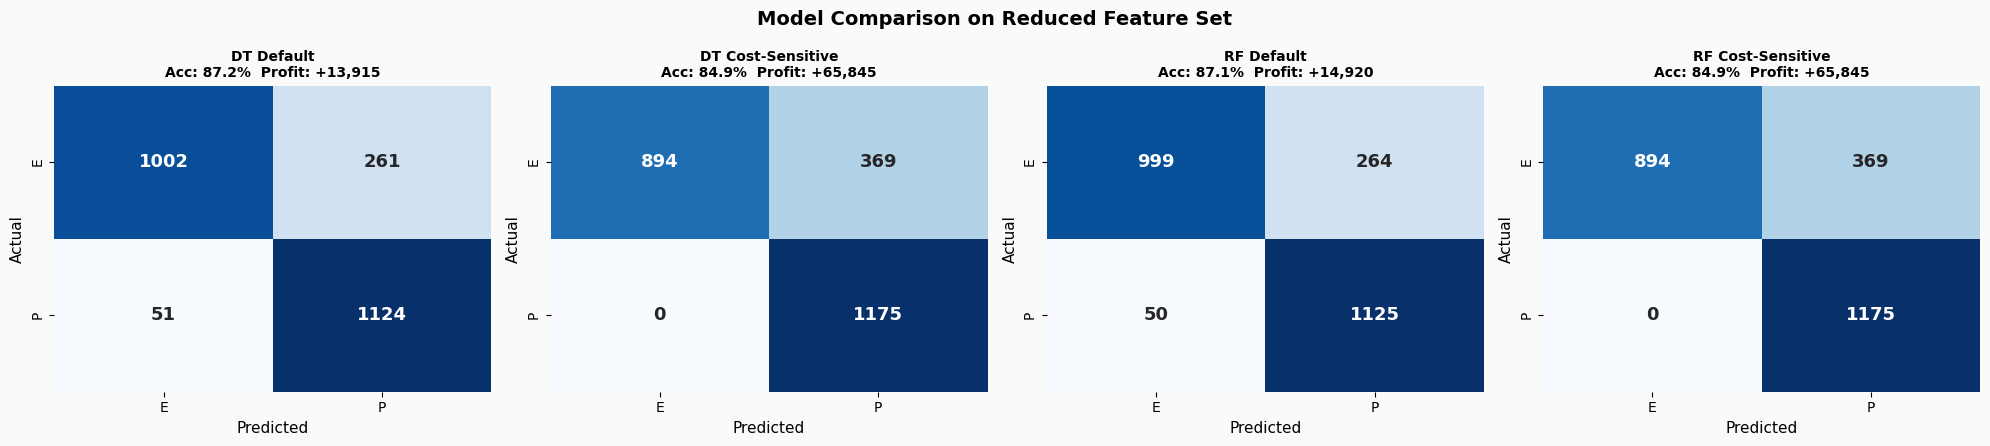

In [17]:
# ── 4-way comparison ──
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
fig.suptitle('Model Comparison on Reduced Feature Set', fontweight='bold', fontsize=14)

configs = [
    (cm_reduced, f'DT Default\nAcc: {acc_reduced*100:.1f}%  Profit: {profit_reduced:+,}'),
    (cm_cost, f'DT Cost-Sensitive\nAcc: {acc_cost*100:.1f}%  Profit: {profit_cost:+,}'),
    (cm_rf_red, f'RF Default\nAcc: {acc_rf_red*100:.1f}%  Profit: {profit_rf:+,}'),
    (cm_rf_cost, f'RF Cost-Sensitive\nAcc: {acc_rf_cost*100:.1f}%  Profit: {profit_rf_cost:+,}'),
]

for ax, (cm, title) in zip(axes, configs):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['E', 'P'], yticklabels=['E', 'P'],
                annot_kws={'size': 13, 'fontweight': 'bold'})
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## Step 8 — Cross-Validation on Reduced Feature Set

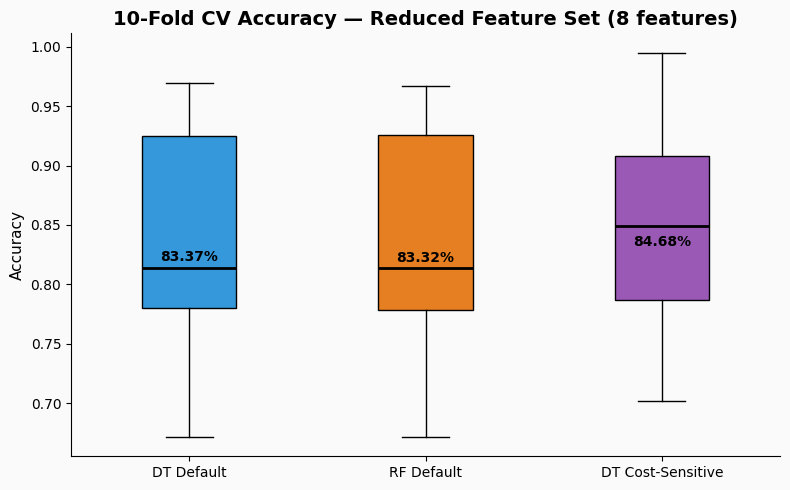

In [18]:
cv_dt_red = cross_val_score(DecisionTreeClassifier(random_state=42),
                            X_reduced, y, cv=10, scoring='accuracy')
cv_rf_red = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                            X_reduced, y, cv=10, scoring='accuracy')
cv_dt_cost_red = cross_val_score(DecisionTreeClassifier(random_state=42, class_weight=class_weights),
                                 X_reduced, y, cv=10, scoring='accuracy')

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot([cv_dt_red, cv_rf_red, cv_dt_cost_red],
                labels=['DT Default', 'RF Default', 'DT Cost-Sensitive'],
                patch_artist=True, widths=0.4,
                medianprops=dict(color='black', linewidth=2))
for box, color in zip(bp['boxes'], ['#3498db', '#e67e22', '#9b59b6']):
    box.set_facecolor(color)

ax.set_title(f'10-Fold CV Accuracy — Reduced Feature Set ({len(kept_features)} features)',
             fontweight='bold')
ax.set_ylabel('Accuracy')
ax.spines[['top', 'right']].set_visible(False)

for i, cv in enumerate([cv_dt_red, cv_rf_red, cv_dt_cost_red], 1):
    ax.text(i, cv.mean() - 0.005, f'{cv.mean()*100:.2f}%',
            ha='center', va='top', fontweight='bold')

plt.tight_layout()
plt.show()

## Step 9 — Decision Tree Visualisation (Reduced Features)

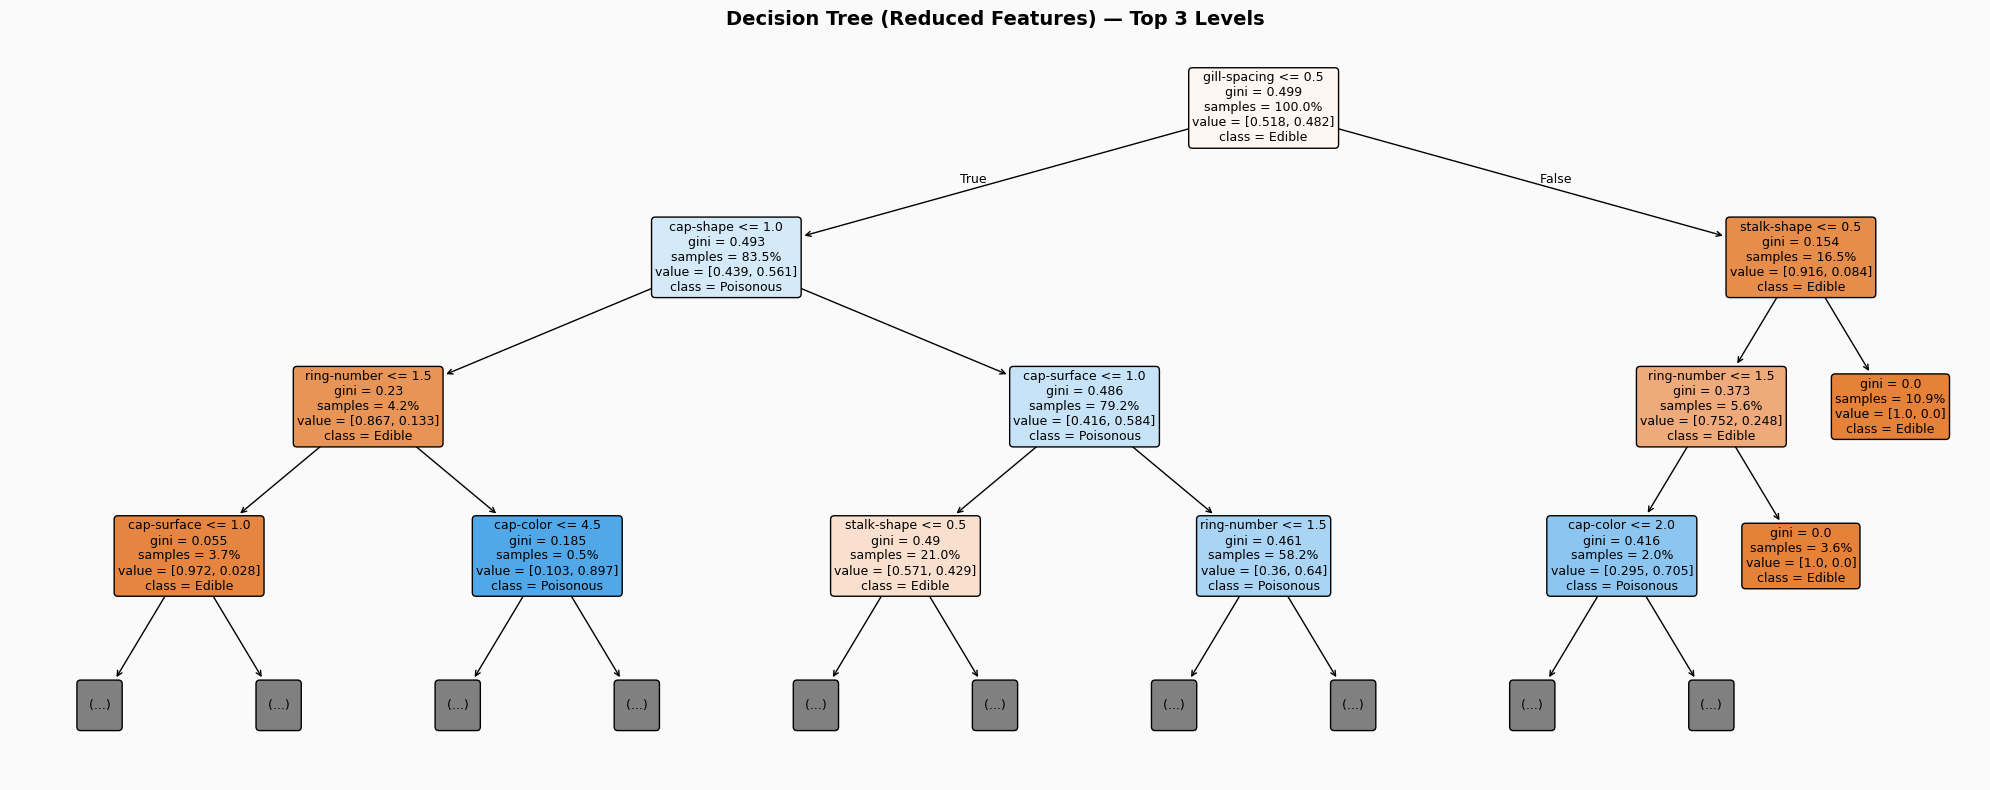

In [21]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt_reduced, max_depth=3, feature_names=kept_features,
          class_names=['Edible', 'Poisonous'],
          filled=True, rounded=True, fontsize=9,
          proportion=True, ax=ax)
ax.set_title('Decision Tree (Reduced Features) — Top 3 Levels', fontweight='bold')
plt.tight_layout()
plt.show()

## Summary — Iteration 2

| Aspect | Result |
|---|---|
| **Method** | Progressive removal of most-informative features by conditional entropy |
| **Features removed** | See above — starting with odor, gill-color, spore-print-color, etc. |
| **First misclassification** | Appears after removing ~N features |
| **FN vs FP** | FN (poison→edible) is far more dangerous |
| **Profit matrix** | TP=+50, TN=+10, FP=−5, FN=−1000 |
| **Cost-sensitive model** | Trades accuracy for reduced FN count → higher profit |
| **Random Forest** | Ensemble partially recovers accuracy on reduced features |